# 1.Youtube GRAPH CONSTRUCTION

POST-POST HOMOPHILY GRAPH

In [1]:
import pandas as pd
import networkx as nx
from itertools import combinations

# =====================================================
# LOAD YOUTUBE GRAPH DATASET
# =====================================================

df = pd.read_csv(
    "../../data_preprocess/processed_data/graph_data/youtube_graph.csv"
)

print("=" * 60)
print("YOUTUBE GRAPH DATA")
print("=" * 60)

print(df.shape)

YOUTUBE GRAPH DATA
(18130, 30)


In [2]:
import pandas as pd
import numpy as np
import time

overall_start = time.time()

# Giả sử 'df' là DataFrame chứa dữ liệu YouTube của bà
# =====================================================
# 1. GENERATE NODES
# =====================================================
print("Đang tạo Nodes cho YouTube...")
nodes_df = df.copy().rename(columns={"post_id": "Id"})
nodes_df["Label"] = nodes_df["Id"]
nodes_df.to_csv("youtube_node.csv", index=False, encoding='utf-8')

# =====================================================
# 2. GENERATE EDGES (YOUTUBE NICHE & AUTHORITY)
# =====================================================
edges_list = []

# Sắp xếp theo followers (Subscribers - Trục quyền lực của YouTube)
sorted_df = df.sort_values(by=['followers'], ascending=True)

# --- A. CỤM NỘI DUNG NGÁCH (TOPIC - CLIMATE, GAMING, FINANCE, SCIENCE) ---
# YouTube vận hành cực mạnh theo các "Niches". 
if 'topic' in sorted_df.columns:
    print("Processing YouTube Niche Clusters (Gaming, Finance, Science...)...")
    for topic, group in sorted_df.groupby('topic'):
        if pd.isna(topic): continue
        ids = group['post_id'].values
        if len(ids) < 2: continue
        
        for i in range(len(ids) - 1):
            # Tăng weight cho các chủ đề "đinh" của YouTube theo Baseline
            if topic in ['Climate', 'Gaming', 'Finance', 'Science', 'Politics']:
                weight = 1.9 
            else:
                weight = 1.2
            edges_list.append({
                "Source": ids[i], 
                "Target": ids[i+1],
                "Weight": weight, 
                "Relation": "topic_niche"
            })

# --- B. CỘT XÁC THỰC (VERIFIED - TOP 2 IMPORTANCE) ---
# Dấu tích xanh trên YouTube là bảo chứng cho chất lượng và độ phủ
if 'verified' in sorted_df.columns:
    print("Processing YouTube Authority Network...")
    verified_group = sorted_df[sorted_df['verified'] == 1]
    ids = verified_group['post_id'].values
    if len(ids) >= 2:
        for i in range(len(ids) - 1):
            edges_list.append({
                "Source": ids[i], 
                "Target": ids[i+1],
                "Weight": 1.6, 
                "Relation": "authority_link"
            })

# --- C. NGÔN NGỮ & ĐỊA ĐIỂM (JAPANESE & LOCATION UNKNOWN) ---
# YouTube có xu hướng phân phối nội dung theo vùng ngôn ngữ cực tốt
if 'language' in sorted_df.columns:
    print("Processing YouTube Language Hubs...")
    for lang, group in sorted_df.groupby('language'):
        ids = group['post_id'].values
        if len(ids) < 2: continue
        for i in range(len(ids) - 1):
            # Ưu tiên tiếng Nhật (Japanese) theo Baseline
            weight = 1.5 if lang == 'Japanese' else 1.0
            edges_list.append({
                "Source": ids[i], 
                "Target": ids[i+1],
                "Weight": weight, 
                "Relation": "language_cluster"
            })

# --- D. POLLS & COMMUNITY ENGAGEMENT (MEDIA TYPE POLL) ---
# Các bài đăng cộng đồng (Poll) giúp kết nối Creator với Fan ngoài video
if 'media_type' in sorted_df.columns:
    print("Processing YouTube Community Poll Connections...")
    poll_group = sorted_df[sorted_df['media_type'] == 'Poll']
    ids = poll_group['post_id'].values
    if len(ids) >= 2:
        for i in range(len(ids) - 1):
            edges_list.append({
                "Source": ids[i], 
                "Target": ids[i+1],
                "Weight": 1.3, 
                "Relation": "poll_engagement"
            })

# --- E. ĐỘ TOXIC & THẢO LUẬN (TOXICITY SCORE) ---
# Những video gây tranh cãi thường có lượng comment "khủng"
if 'toxicity_score' in sorted_df.columns:
    print("Processing YouTube Discussion Intensity...")
    temp_df = sorted_df.copy()
    temp_df['toxic_bins'] = temp_df['toxicity_score'].apply(lambda x: round(x/10)*10)
    for val, group in temp_df.groupby('toxic_bins'):
        ids = group['post_id'].values
        if len(ids) < 2: continue
        for i in range(len(ids) - 1):
            edges_list.append({
                "Source": ids[i], 
                "Target": ids[i+1],
                "Weight": 0.9, 
                "Relation": "debate_vibe"
            })

# --- F. QUAN HỆ KÊNH (USER-ID / CHANNEL) ---
# Hệ sinh thái của một Channel (các video liên quan của cùng 1 người)
print("Processing YouTube Channel Ecosystems...")
for user_id, group in sorted_df.groupby('user_id'):
    ids = group['post_id'].values
    if len(ids) >= 2:
        for i in range(len(ids) - 1):
            edges_list.append({
                "Source": ids[i], 
                "Target": ids[i+1],
                "Weight": 2.2, # Sự trung thành với kênh là cốt lõi của YouTube
                "Relation": "same_channel"
            })

# =====================================================
# 3. CLEAN & EXPORT
# =====================================================
edges_df = pd.DataFrame(edges_list)
if not edges_df.empty:
    edges_df[['Source', 'Target']] = np.sort(edges_df[['Source', 'Target']], axis=1)
    edges_df = edges_df.drop_duplicates(subset=['Source', 'Target', 'Relation'])
    edges_df = edges_df[edges_df['Source'] != edges_df['Target']]

edges_df.to_csv("youtube_edge.csv", index=False, encoding='utf-8')

print(f"\n--- THÀNH PHẨM YOUTUBE GRAPH ---")
print(f"Nodes: {len(nodes_df):,}")
print(f"Edges: {len(edges_df):,}")
print(f"Time: {round(time.time() - overall_start, 2)}s")

Đang tạo Nodes cho YouTube...
Processing YouTube Niche Clusters (Gaming, Finance, Science...)...
Processing YouTube Authority Network...
Processing YouTube Language Hubs...
Processing YouTube Community Poll Connections...
Processing YouTube Discussion Intensity...
Processing YouTube Channel Ecosystems...

--- THÀNH PHẨM YOUTUBE GRAPH ---
Nodes: 18,130
Edges: 56,273
Time: 0.67s


In [3]:
import pandas as pd

graph_df = pd.read_csv(
    "fb-result-4.csv"
)

print("\n" + "=" * 60)
print("GRAPH FEATURES DATA")
print("=" * 60)

print(graph_df.shape)

print("\nColumns:")
print(graph_df.columns.tolist())


GRAPH FEATURES DATA
(7527, 43)

Columns:
['Id', 'platform', 'hour_of_day', 'day_of_week', 'is_weekend', 'user_id', 'followers', 'account_age_days', 'verified', 'topic', 'language', 'content_length', 'media_type', 'num_hashtags', 'sentiment_category', 'sentiment_positive', 'sentiment_negative', 'sentiment_neutral', 'toxicity_score', 'location', 'hour_sin', 'hour_cos', 'day_sin', 'day_cos', 'has_media', 'many_hashtags', 'long_content', 'sentiment_intensity', 'high_toxicity', 'popularity', 'modularity_class', 'stat_inf_class', 'clustering', 'triangles', 'eigencentrality', 'Eccentricity', 'closnesscentrality', 'harmonicclosnesscentrality', 'betweenesscentrality', 'Authority', 'Hub', 'pageranks', 'componentnumber']


In [4]:
# SELECT ONLY USEFUL GRAPH FEATURES
# =====================================================

graph_features = graph_df[[
    "Id",
    "betweenesscentrality",
    "eigencentrality",
    "pageranks",
    "closnesscentrality",
    "triangles"
]]
graph_features = graph_features.rename(
    columns={
        "Id": "post_id"
    }
)

print("\nGraph Features Shape:")
print(graph_features.shape)



Graph Features Shape:
(7527, 6)


In [5]:
original_df = df.copy()

# =====================================================
# REMOVE DUPLICATES
# =====================================================

original_df = original_df.drop_duplicates(
    subset=["post_id"]
)

In [6]:
# MERGE POST_ID BACK TO TRAIN/TEST
# =====================================================
# We need mapping between rows
# =====================================================

# recreate metadata version
metadata_df = original_df.copy()

remove_cols = [
    
    "timestamp",
    "date",
    "platform",
    "likes",
    "shares",
    "comments",
    "views",
    "total_engagement",
    "engagement_rate_per_1k_followers",
    "viral_coefficient",
    "cross_platform_spread",
    "hours_since_post"
]

existing_remove_cols = [

    col for col in remove_cols
    if col in metadata_df.columns
]

metadata_df = metadata_df.drop(
    columns=existing_remove_cols
)


In [7]:
# =====================================================
# ONE-HOT ENCODING
# =====================================================

categorical_cols = [

    "topic",
    "language",
    "media_type",
    "sentiment_category",
    "location"
]

existing_categorical_cols = [

    col for col in categorical_cols
    if col in metadata_df.columns
]

metadata_df = pd.get_dummies(

    metadata_df,

    columns=existing_categorical_cols,

    drop_first=True
)


In [8]:
# LOAD FACEBOOK TRAIN / TEST
# =====================================================

train_df = pd.read_csv(
    "../../data_preprocess/processed_data/ml_data/facebook_train.csv"
)

test_df = pd.read_csv(
    "../../data_preprocess/processed_data/ml_data/facebook_test.csv"
)

print("=" * 60)
print("METADATA DATASETS")
print("=" * 60)

print("Train Shape:", train_df.shape)
print("Test Shape :", test_df.shape)

METADATA DATASETS
Train Shape: (6021, 56)
Test Shape : (1506, 56)


In [9]:
# MERGE TRAIN
# =====================================================

train_hybrid = train_df.merge(

    graph_features,

    on="post_id",
    how="left"
)

# =====================================================
# MERGE TEST
# =====================================================

test_hybrid = test_df.merge(

    graph_features,

    on="post_id",
    how="left"
)

In [ ]:

print("\n" + "="*30)
print("Class distribution in the training set")
print("="*30)
print(train_df["popularity"].value_counts())
print("\nTỷ lệ %:")
print(train_df["popularity"].value_counts(normalize=True) * 100)

print("\n" + "="*30)
print("Class distribution in the test set")
print("="*30)
print(test_df["popularity"].value_counts())
print("\nTỷ lệ %:")
print(test_df["popularity"].value_counts(normalize=True) * 100)


PHÂN BỔ LỚP TRONG TẬP TRAIN
popularity
0    4812
1    1209
Name: count, dtype: int64

Tỷ lệ %:
popularity
0    79.920279
1    20.079721
Name: proportion, dtype: float64

PHÂN BỔ LỚP TRONG TẬP TEST
popularity
0    1204
1     302
Name: count, dtype: int64

Tỷ lệ %:
popularity
0    79.946879
1    20.053121
Name: proportion, dtype: float64


In [ ]:

negative_count = train_df["popularity"].value_counts()[0]
positive_count = train_df["popularity"].value_counts()[1]

ratio = negative_count / positive_count
print(f"Class imbalance detected! scale_pos_weight = {ratio:.2f}")

Đã kích hoạt chống lười! Trọng số scale_pos_weight = 3.98


In [ ]:
# FILL MISSING VALUES IN GRAPH FEATURES
# =====================================================

numeric_graph_cols = [
    "betweenesscentrality", 
    "eigencentrality",
    "pageranks",
    "Weighted Degree",
    "triangles"
]

existing_numeric_cols = [col for col in numeric_graph_cols if col in train_hybrid.columns]

train_hybrid[existing_numeric_cols] = train_hybrid[existing_numeric_cols].fillna(0)
test_hybrid[existing_numeric_cols]  = test_hybrid[existing_numeric_cols].fillna(0)

X_train_cols = train_hybrid.columns
test_hybrid = test_hybrid.reindex(columns=X_train_cols, fill_value=0)

print("\n" + "=" * 60)
print("HYBRID DATASETS - CLEANED & ALIGNED")
print("=" * 60)
print(f"Train Hybrid: {train_hybrid.shape}")
print(f"Test Hybrid : {test_hybrid.shape}")


HYBRID DATASETS - CLEANED & ALIGNED
Train Hybrid: (6021, 61)
Test Hybrid : (1506, 61)


In [13]:
# SAVE HYBRID DATASETS
# =====================================================

train_hybrid.to_csv(
    "facebook_hybrid_train.csv",
    index=False
)

test_hybrid.to_csv(
    "facebook_hybrid_test.csv",
    index=False
)

In [14]:
# =====================================================
# INSTAGRAM HYBRID MODEL
# METADATA + GRAPH FEATURES
# =====================================================

from xgboost import XGBClassifier

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    classification_report,
    confusion_matrix
)

In [15]:
# LOAD HYBRID DATASETS
# =====================================================

train_df = pd.read_csv(
    "facebook_hybrid_train.csv"
)

test_df = pd.read_csv(
    "facebook_hybrid_test.csv"
)

print("=" * 60)
print("HYBRID DATASETS")
print("=" * 60)

print("Train Shape:", train_df.shape)
print("Test Shape :", test_df.shape)

HYBRID DATASETS
Train Shape: (6021, 61)
Test Shape : (1506, 61)


In [16]:
# DROP ID COLUMNS
# =====================================================

drop_cols = [

    "post_id",
    "user_id"
]

existing_drop_cols = [

    col for col in drop_cols
    if col in train_df.columns
]

train_df = train_df.drop(
    columns=existing_drop_cols
)

test_df = test_df.drop(
    columns=existing_drop_cols
)

In [18]:
# SPLIT FEATURES / TARGET
# =====================================================

X_train = train_df.drop(
    columns=["popularity"]
)

y_train = train_df["popularity"]

X_test = test_df.drop(
    columns=["popularity"]
)

y_test = test_df["popularity"]

print("\nX_train Shape:", X_train.shape)
print("X_test Shape :", X_test.shape)


X_train Shape: (6021, 56)
X_test Shape : (1506, 56)


In [19]:
from xgboost import XGBClassifier
model = XGBClassifier(
    objective="binary:logistic",
    eval_metric="logloss",
    scale_pos_weight=ratio,     # Handle imbalanced data
    n_estimators=500,           # Number of boosting rounds
    learning_rate=0.02,         # Step size shrinkage
    max_depth=6,                # Maximum tree depth
    min_child_weight=1,         # Minimum sum of instance weight
    gamma=0.1,                  # Minimum loss reduction
    subsample=0.8,              # Fraction of training data per tree
    colsample_bytree=0.5,       # Fraction of features per tree
    random_state=42,            # For reproducibility
    n_jobs=-1                   # Use all CPU cores
)

In [20]:
# TRAIN MODEL
# =====================================================

print("\n" + "=" * 60)
print("TRAINING HYBRID MODEL...")
print("=" * 60)

model.fit(
    X_train,
    y_train
)


TRAINING HYBRID MODEL...


,"objective objective: typing.Union[str, xgboost.sklearn._SklObjWProto, typing.Callable[[typing.Any, typing.Any], typing.Tuple[numpy.ndarray, numpy.ndarray]], NoneType]Specify the learning task and the corresponding learning objective or a customobjective function to be used.For custom objective, see :doc:`/tutorials/custom_metric_obj` and:ref:`custom-obj-metric` for more information, along with the end note forfunction signatures.",'binary:logistic'
,"base_score base_score: typing.Union[float, typing.List[float], NoneType]The initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.Optional[typing.List[xgboost.callback.TrainingCallback]]List of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API `... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: typing.Optional[float]Subsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: typing.Optional[float]Subsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: typing.Optional[float]Subsample ratio of columns when constructing each tree.,0.5
,"device device: typing.Optional[str].. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: typing.Optional[int].. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",None
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,False
,"eval_metric eval_metric: typing.Union[str, typing.List[typing.Union[str, typing.Callable]], typing.Callable, NoneType].. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import load_diabetes f

In [21]:
# PREDICTIONS
# =====================================================

y_pred = model.predict(X_test)

y_prob = model.predict_proba(X_test)[:, 1]

In [22]:
# EVALUATION
# =====================================================

accuracy = accuracy_score(
    y_test,
    y_pred
)

precision = precision_score(
    y_test,
    y_pred
)

recall = recall_score(
    y_test,
    y_pred
)

f1 = f1_score(
    y_test,
    y_pred
)

roc_auc = roc_auc_score(
    y_test,
    y_prob
)

In [23]:
# CLASSIFICATION REPORT
# =====================================================

print("\n" + "=" * 60)
print("CLASSIFICATION REPORT")
print("=" * 60)

print(
    classification_report(
        y_test,
        y_pred
    )
)

print(f"ROC-AUC  : {roc_auc:.4f}")


CLASSIFICATION REPORT
              precision    recall  f1-score   support

           0       0.92      0.83      0.87      1204
           1       0.50      0.70      0.59       302

    accuracy                           0.80      1506
   macro avg       0.71      0.76      0.73      1506
weighted avg       0.83      0.80      0.81      1506

ROC-AUC  : 0.8607


In [24]:
# CONFUSION MATRIX
# =====================================================

cm = confusion_matrix(
    y_test,
    y_pred
)

print("\n" + "=" * 60)
print("CONFUSION MATRIX")
print("=" * 60)

print(cm)


CONFUSION MATRIX
[[995 209]
 [ 90 212]]


In [25]:
# FEATURE IMPORTANCE
# =====================================================

importance_df = pd.DataFrame({

    "feature": X_train.columns,
    "importance": model.feature_importances_

})

importance_df = importance_df.sort_values(
    by="importance",
    ascending=False
)

print("\n" + "=" * 60)
print("TOP 20 IMPORTANT FEATURES")
print("=" * 60)

print(
    importance_df.head(20)
)


TOP 20 IMPORTANT FEATURES
                 feature  importance
3              followers    0.146195
5               verified    0.041680
54    closnesscentrality    0.023069
37     language_Japanese    0.018336
21   topic_Entertainment    0.017466
52       eigencentrality    0.017216
31          topic_Travel    0.017151
35       language_German    0.016898
28         topic_Science    0.016850
4       account_age_days    0.016839
19         topic_Climate    0.016640
6         content_length    0.016607
16   sentiment_intensity    0.016366
45         location_Asia    0.016348
8         toxicity_score    0.016300
34       language_French    0.016280
51  betweenesscentrality    0.016183
40      language_Spanish    0.016054
26          topic_Health    0.015827
50      location_Unknown    0.015631


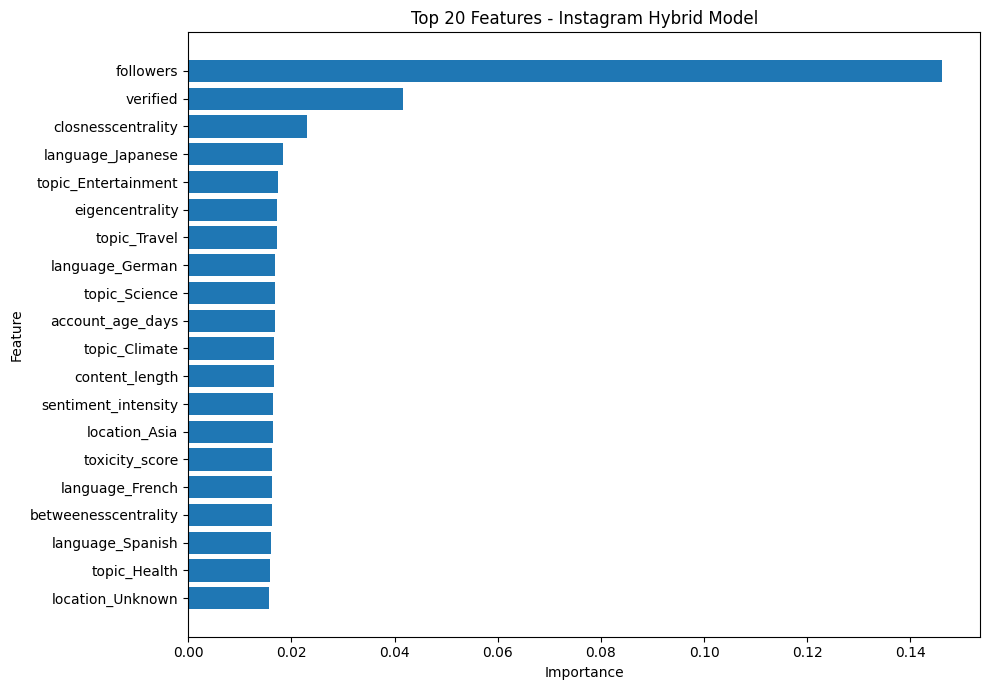

In [26]:
# PLOT TOP FEATURES
# =====================================================
import matplotlib.pyplot as plt

top_n = 20

plot_df = importance_df.head(top_n)

plt.figure(figsize=(10, 7))

plt.barh(
    plot_df["feature"][::-1],
    plot_df["importance"][::-1]
)

plt.xlabel("Importance")
plt.ylabel("Feature")

plt.title(
    "Top 20 Features - Instagram Hybrid Model"
)

plt.tight_layout()

plt.show()

# 2. FACEBOOK NODE2VEC

 GRAPH EMBEDDING

In [ ]:
import pandas as pd
import os
import networkx as nx

import time

start_time = time.time()

# 1. Just load edges, nodes
# =====================================================
print("Đang nạp file Edges...")
edges_df = pd.read_csv("fb_edge.csv") 

# 2. Building NetworkX Graph...
# =====================================================
print("Đang xây dựng NetworkX Graph...")
G = nx.from_pandas_edgelist(
    edges_df, 
    source="Source", 
    target="Target", 
    create_using=nx.Graph() 
)

print(f"Graph Created  | Nodes: {G.number_of_nodes():,} | Edges: {G.number_of_edges():,}")


print("TRAINING NODE2VEC (MULTI-CORE)...")


so_loi_cpu = os.cpu_count()
print(f" Your laptop has {so_loi_cpu} CPU cores. Mobilizing all cores... " )

print("\n" + "=" * 60)
print("TRAINING NODE2VEC (MULTI-CORE UPDATE)...")
print("=" * 60)



Đang nạp file Edges...
Đang xây dựng NetworkX Graph...
Graph Created 🚀 | Nodes: 7,527 | Edges: 31,490
TRAINING NODE2VEC (MULTI-CORE)...
👉 Máy của bà đang có 22 lõi CPU. Đang huy động toàn bộ...

TRAINING NODE2VEC (MULTI-CORE CẬP NHẬT)...


In [ ]:
from node2vec import Node2Vec
import time

node2vec = Node2Vec(
    G,
    dimensions=8,        
    walk_length=10,      
    num_walks=20,        
    workers=so_loi_cpu,  
    seed=42,
    quiet=False          
)

model = node2vec.fit(
    window=5, 
    min_count=1, 
    batch_words=4     
)

print("\nNode2Vec done")

print(f"\nNode2Vec done after: {round((time.time() - start_time)/60, 2)} minutes ")



Computing transition probabilities:   0%|          | 0/7527 [00:00<?, ?it/s]


Node2Vec hoàn thành 🚀

Node2Vec hoàn thành sau: 1.83 phút 🚀


In [ ]:
# 4.Split and save vectors 
# =====================================================
print("Exporting Embeddings to DataFrame...")

node_ids = list(model.wv.index_to_key)
embeddings = model.wv.vectors

emb_df = pd.DataFrame(embeddings, columns=[f"emb_{i}" for i in range(8)])
emb_df["post_id"] = node_ids 

emb_df = emb_df[emb_df['post_id'].astype(str).str.startswith('FAC')]


emb_df.to_csv("facebook_node2vec_8dims.csv", index=False)
print(f"Successfully saved {len(emb_df)} vectors of Post articles!")

Đang xuất Embeddings ra DataFrame...
Đã lưu thành công 7527 vectors của bài Post!


In [59]:
# FACEBOOK NODE2VEC HYBRID MODEL
# METADATA + NODE2VEC EMBEDDINGS
# =====================================================

import pandas as pd
import numpy as np

from xgboost import XGBClassifier

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    classification_report
)

import matplotlib.pyplot as plt

In [61]:
# LOAD TRAIN / TEST DATA
# =====================================================

train_df = pd.read_csv(
    "../../data_preprocess/processed_data/ml_data/facebook_train.csv"
)

test_df = pd.read_csv(
    "../../data_preprocess/processed_data/ml_data/facebook_test.csv"
)

print("=" * 60)
print("METADATA DATA")
print("=" * 60)

print("Train Shape:", train_df.shape)
print("Test Shape :", test_df.shape)

METADATA DATA
Train Shape: (6021, 56)
Test Shape : (1506, 56)


In [62]:
#LOAD NODE2VEC EMBEDDINGS
# =====================================================

embedding_df = pd.read_csv(
    "facebook_node2vec_8dims.csv"
)

print("\n" + "=" * 60)
print("NODE2VEC EMBEDDINGS")
print("=" * 60)

print(embedding_df.shape)

print("\nEmbedding Columns:")
print(embedding_df.columns[:10])


NODE2VEC EMBEDDINGS
(7527, 9)

Embedding Columns:
Index(['emb_0', 'emb_1', 'emb_2', 'emb_3', 'emb_4', 'emb_5', 'emb_6', 'emb_7',
       'post_id'],
      dtype='str')


In [63]:
# MERGE TRAIN
# =====================================================

train_hybrid = train_df.merge(

    embedding_df,

    on="post_id",
    how="left"
)

# =====================================================
# MERGE TEST
# =====================================================

test_hybrid = test_df.merge(

    embedding_df,

    on="post_id",
    how="left"
)

# =====================================================
# CHECK MISSING VALUES
# =====================================================

print("\n" + "=" * 60)
print("MISSING EMBEDDINGS CHECK")
print("=" * 60)

embedding_cols = [

    col for col in embedding_df.columns
    if col.startswith("n2v_")
]

print("\nTrain Missing:")

print(
    train_hybrid[
        embedding_cols
    ].isnull().sum().sum()
)

print("\nTest Missing:")

print(
    test_hybrid[
        embedding_cols
    ].isnull().sum().sum()
)

# =====================================================
# FILL MISSING EMBEDDINGS
# =====================================================

train_hybrid[embedding_cols] = train_hybrid[
    embedding_cols
].fillna(0)

test_hybrid[embedding_cols] = test_hybrid[
    embedding_cols
].fillna(0)

# =====================================================
# DROP ID COLUMNS
# =====================================================

drop_cols = [

    "post_id",
    "user_id"
]

existing_drop_cols = [

    col for col in drop_cols
    if col in train_hybrid.columns
]

train_hybrid = train_hybrid.drop(
    columns=existing_drop_cols
)

test_hybrid = test_hybrid.drop(
    columns=existing_drop_cols
)


MISSING EMBEDDINGS CHECK

Train Missing:
0.0

Test Missing:
0.0


In [64]:
# SPLIT FEATURES / TARGET
# =====================================================

X_train = train_hybrid.drop(
    columns=["popularity"]
)

y_train = train_hybrid["popularity"]

X_test = test_hybrid.drop(
    columns=["popularity"]
)

y_test = test_hybrid["popularity"]

print("\n" + "=" * 60)
print("FINAL DATA")
print("=" * 60)

print("X_train:", X_train.shape)
print("X_test :", X_test.shape)



FINAL DATA
X_train: (6021, 61)
X_test : (1506, 61)


In [ ]:
# =====================================================
# XGBOOST MODEL

from xgboost import XGBClassifier
model = XGBClassifier(
    objective="binary:logistic",
    eval_metric="logloss",
    
    scale_pos_weight=ratio,      
    
    # CÁC THAM SỐ CÂY TỐI ƯU
    n_estimators=300,            
    learning_rate=0.05,          
    max_depth=5,                
    subsample=0.8,               
    colsample_bytree=0.5,        
    colsample_bylevel=0.5,
    reg_alpha=1.0,               
    reg_lambda=2.0,              
    random_state=42,
    n_jobs=-1
)
# =====================================================
# TRAIN MODEL
# =====================================================

print("\n" + "=" * 60)
print("TRAINING NODE2VEC HYBRID MODEL...")
print("=" * 60)

model.fit(
    X_train,
    y_train
)

print("Training completed ")

# =====================================================
# PREDICTIONS
# =====================================================

y_pred = model.predict(X_test)

y_prob = model.predict_proba(X_test)[:, 1]

# =====================================================
# EVALUATION
# =====================================================

accuracy = accuracy_score(
    y_test,
    y_pred
)

precision = precision_score(
    y_test,
    y_pred
)

recall = recall_score(
    y_test,
    y_pred
)

f1 = f1_score(
    y_test,
    y_pred
)

roc_auc = roc_auc_score(
    y_test,
    y_prob
)


TRAINING NODE2VEC HYBRID MODEL...
Training completed 🚀


In [109]:
# =====================================================
# CLASSIFICATION REPORT
# =====================================================

print("\n" + "=" * 60)
print("CLASSIFICATION REPORT")
print("=" * 60)

print(
    classification_report(
        y_test,
        y_pred
    )
)
print(f"ROC-AUC  : {roc_auc:.4f}")


CLASSIFICATION REPORT
              precision    recall  f1-score   support

           0       0.92      0.83      0.87      1204
           1       0.51      0.70      0.59       302

    accuracy                           0.80      1506
   macro avg       0.71      0.76      0.73      1506
weighted avg       0.83      0.80      0.81      1506

ROC-AUC  : 0.8515


In [110]:
# FEATURE IMPORTANCE
# =====================================================

importance_df = pd.DataFrame({

    "feature": X_train.columns,
    "importance": model.feature_importances_

})

importance_df = importance_df.sort_values(
    by="importance",
    ascending=False
)

print("\n" + "=" * 60)
print("TOP 20 IMPORTANT FEATURES")
print("=" * 60)

print(
    importance_df.head(20)
)


TOP 20 IMPORTANT FEATURES
                   feature  importance
3                followers    0.129378
58                   emb_2    0.035382
61                   emb_0    0.032117
60                   emb_4    0.027551
5                 verified    0.025313
63                   emb_5    0.023639
62                   emb_6    0.022878
65                   emb_1    0.021515
64                   emb_3    0.021399
59                   emb_7    0.020436
56      closnesscentrality    0.019885
40         language_Korean    0.015967
39       language_Japanese    0.015868
49  location_North America    0.014193
9       sentiment_negative    0.014089
18     sentiment_intensity    0.013648
33            topic_Travel    0.013442
2               is_weekend    0.013394
52        location_Unknown    0.013281
4         account_age_days    0.013238


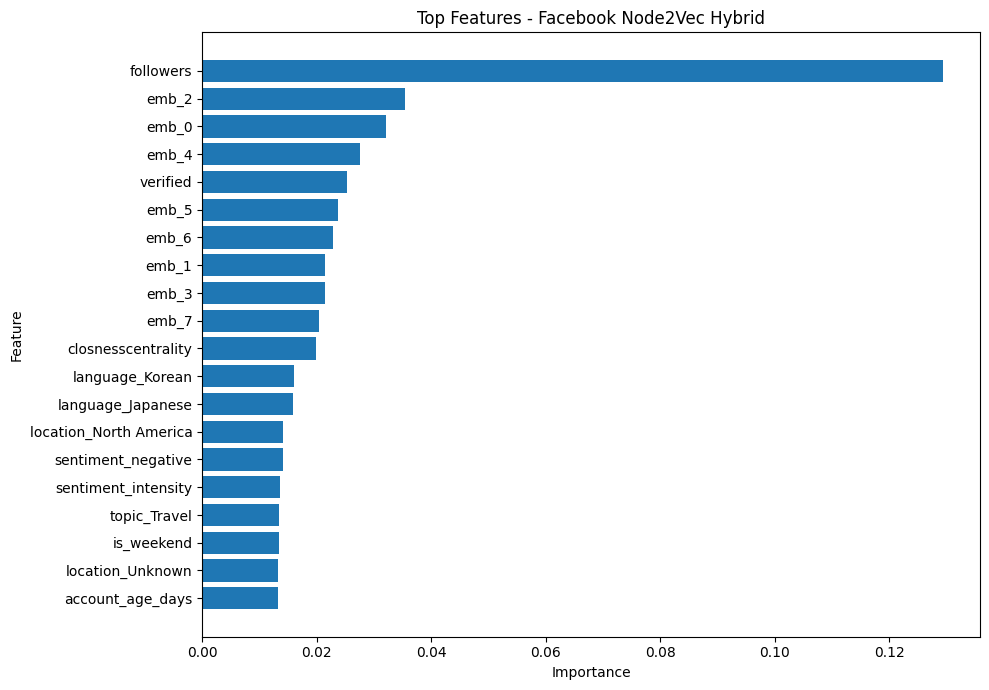

In [111]:
# =====================================================

top_n = 20

plot_df = importance_df.head(top_n)

plt.figure(figsize=(10, 7))

plt.barh(
    plot_df["feature"][::-1],
    plot_df["importance"][::-1]
)

plt.xlabel("Importance")
plt.ylabel("Feature")

plt.title(
    "Top Features - Facebook Node2Vec Hybrid"
)

plt.tight_layout()

plt.show()

# 3. Facebook graph + Node2vector

In [ ]:
selected_n2v = ["emb_2", "emb_7", "emb_4", "emb_0", "emb_6", "emb_5", "emb_3", "emb_1"]

embedding_df_filtered = embedding_df[["post_id"] + [c for c in selected_n2v if c in embedding_df.columns]]

print("---  Done to filter Embeddings  ---")
print(f"Using columns: {embedding_df_filtered.columns.tolist()}")

--- ✅ Đã lọc Embedding tinh gọn ---
Các cột sẽ dùng: ['post_id', 'emb_2', 'emb_7', 'emb_4', 'emb_0', 'emb_6', 'emb_5', 'emb_3', 'emb_1']


In [72]:
train_df = pd.read_csv(
    "facebook_hybrid_train.csv"
)

test_df = pd.read_csv(
    "facebook_hybrid_test.csv"
)

print("=" * 60)
print("GRAPH HYBRID DATA")
print("=" * 60)

print("Train Shape:", train_df.shape)
print("Test Shape :", test_df.shape)

# =====================================================
# LOAD NODE2VEC EMBEDDINGS
# =====================================================

print("\n" + "=" * 60)
print("NODE2VEC EMBEDDINGS")
print("=" * 60)

print(embedding_df.shape)

# =====================================================
# CHECK EMBEDDING KEY
# =====================================================

print("\nEmbedding Columns:")
print(embedding_df.columns)


GRAPH HYBRID DATA
Train Shape: (6021, 61)
Test Shape : (1506, 61)

NODE2VEC EMBEDDINGS
(7527, 9)

Embedding Columns:
Index(['emb_0', 'emb_1', 'emb_2', 'emb_3', 'emb_4', 'emb_5', 'emb_6', 'emb_7',
       'post_id'],
      dtype='str')


In [ ]:
# 2. MERGE INTO DATA HYBRID 
# =====================================================
# Merge into Train set
train_final = train_df.merge(embedding_df_filtered, on="post_id", how="left")

# Merge into Test set
test_final = test_df.merge(embedding_df_filtered, on="post_id", how="left")

print(f"\n---  Done merging Embeddings  ---")
print(f"Train Shape: {train_final.shape} | Test Shape: {test_final.shape}")


--- ✅ Đã Merge xong ---
Train Shape: (6021, 69) | Test Shape: (1506, 69)


In [ ]:
# 3. Process missing values
actual_emb_cols = [col for col in train_final.columns if col.startswith("emb_")]

print(f"\n Checking missing values for {len(actual_emb_cols)} embedding columns...")

train_final[actual_emb_cols] = train_final[actual_emb_cols].fillna(0)
test_final[actual_emb_cols] = test_final[actual_emb_cols].fillna(0)

print(f"Missing values after fill: {train_final[actual_emb_cols].isnull().sum().sum()}")


🔍 Đang kiểm tra Missing cho 8 cột embedding...
Missing sau khi fill: 0


In [ ]:
# =====================================================
# 4. DROP COLUMNS (POST_ID, USER_ID)
# =====================================================
drop_cols = ["post_id", "user_id"]
existing_drop_cols = [col for col in drop_cols if col in train_final.columns]

train_final = train_final.drop(columns=existing_drop_cols)
test_final = test_final.drop(columns=existing_drop_cols)

print(f"\n--- Done ---")
print(f"Final number of features: {train_final.shape[1]} features.")


--- 🚀 HOÀN TẤT ---
Dữ liệu cuối cùng: 67 features.


In [76]:
# SPLIT FEATURES / TARGET
# =====================================================

X_train = train_final.drop(
    columns=["popularity"]
)

y_train = train_final["popularity"]

X_test = test_final.drop(
    columns=["popularity"]
)

y_test = test_final["popularity"]

print("\n" + "=" * 60)
print("FINAL FEATURE SPACE")
print("=" * 60)

print("X_train:", X_train.shape)
print("X_test :", X_test.shape)


FINAL FEATURE SPACE
X_train: (6021, 66)
X_test : (1506, 66)


In [114]:
# XGBOOST MODEL
# =====================================================

# XGBOOST MODEL
from xgboost import XGBClassifier
model = XGBClassifier(
    objective="binary:logistic",
    eval_metric="logloss",
    scale_pos_weight=ratio,     # Handle imbalanced data
    n_estimators=500,           # Number of boosting rounds
    learning_rate=0.02,         # Step size shrinkage
    max_depth=6,                # Maximum tree depth
    min_child_weight=1,         # Minimum sum of instance weight
    gamma=0.1,                  # Minimum loss reduction
    subsample=0.8,              # Fraction of training data per tree
    colsample_bytree=0.7,       # Fraction of features per tree
    random_state=42,            # For reproducibility
    n_jobs=-1                   # Use all CPU cores
)

# =====================================================
# TRAIN MODEL
# =====================================================

print("\n" + "=" * 60)
print("TRAINING FINAL FACEBOOK META + GRAPH + EMBEDDING...")
print("=" * 60)

model.fit(
    X_train,
    y_train
)

print("\nTraining completed 🚀")

# =====================================================
# PREDICTIONS
# =====================================================

y_pred = model.predict(X_test)

y_prob = model.predict_proba(X_test)[:, 1]


TRAINING FINAL FACEBOOK META + GRAPH + EMBEDDING...

Training completed 🚀


In [115]:
accuracy = accuracy_score(
    y_test,
    y_pred
)

precision = precision_score(
    y_test,
    y_pred
)

recall = recall_score(
    y_test,
    y_pred
)

f1 = f1_score(
    y_test,
    y_pred
)

roc_auc = roc_auc_score(
    y_test,
    y_prob
)


In [116]:


# =====================================================
# CLASSIFICATION REPORT
# =====================================================

print("\n" + "=" * 60)
print("CLASSIFICATION REPORT")
print("=" * 60)

print(
    classification_report(
        y_test,
        y_pred
    )
)
print(f"ROC-AUC  : {roc_auc:.4f}")


CLASSIFICATION REPORT
              precision    recall  f1-score   support

           0       0.91      0.84      0.88      1204
           1       0.52      0.68      0.59       302

    accuracy                           0.81      1506
   macro avg       0.72      0.76      0.73      1506
weighted avg       0.83      0.81      0.82      1506

ROC-AUC  : 0.8553


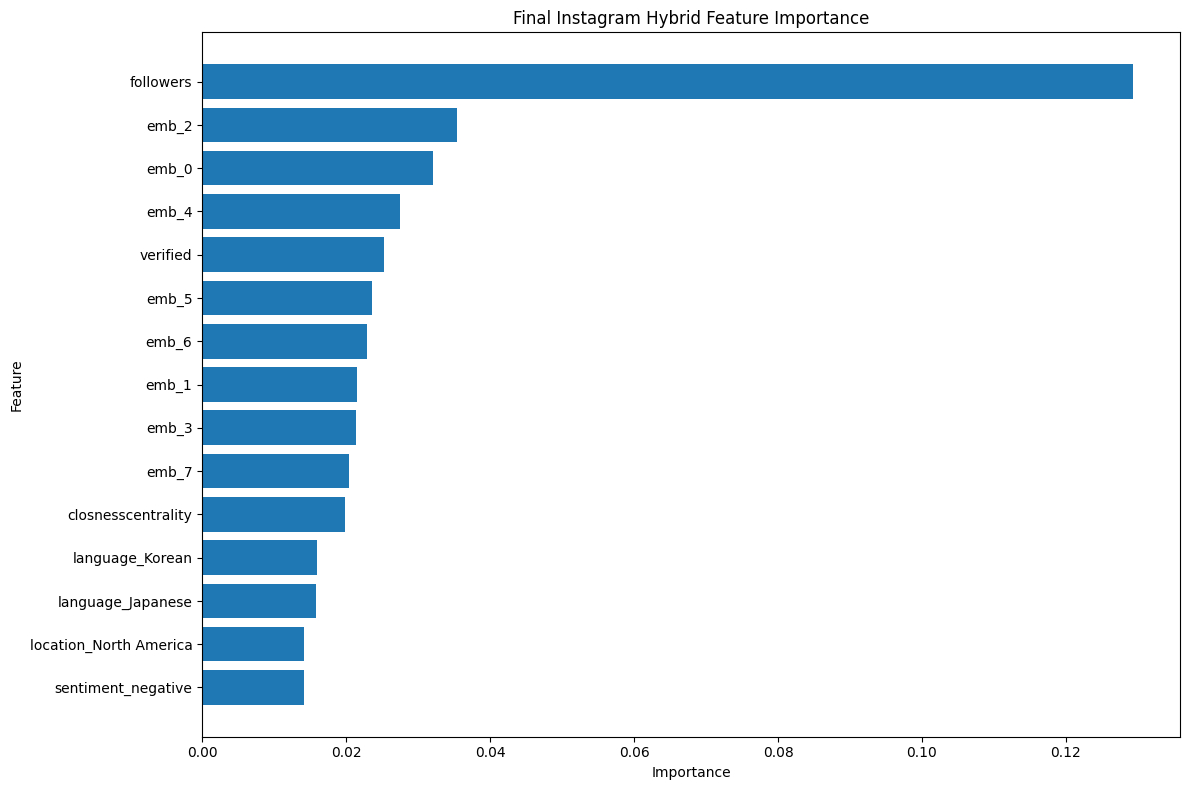

In [117]:
# PLOT FEATURE IMPORTANCE
# =====================================================

top_n = 15

plot_df = importance_df.head(top_n)

plt.figure(figsize=(12, 8))

plt.barh(

    plot_df["feature"][::-1],

    plot_df["importance"][::-1]
)

plt.xlabel("Importance")

plt.ylabel("Feature")

plt.title(
    "Final Instagram Hybrid Feature Importance"
)

plt.tight_layout()

plt.show()